# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
# Load the cleaned data
airline_df = pd.read_csv('cleaned_aviation_data.csv', index_col=0)

# Check 
airline_df.shape

(17879, 32)

Observation: The cleaned dataset has been successfully loaded with 17,879 rows and 32 columns.


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# Separate small and large planes
small_planes = airline_df[airline_df['total_passengers'] <= 20]
large_planes = airline_df[airline_df['total_passengers'] > 20]

# Check sizes
print("Small planes:", small_planes.shape)
print("Large planes:", large_planes.shape)

Small planes: (17006, 32)
Large planes: (873, 32)


Observation: Using a threshold of 20 passengers, the dataset has been split into 17,006 small plane records and 873 large plane records.Small planes make up the majority of accidents in our dataset.


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [4]:
# 15 lowest mean injury fraction for small planes
small_makes = small_planes.groupby('make')['injury_fraction'].mean().sort_values().head(15)
print(small_makes)

make
Bombardier Inc                    0.090909
Mcdonnell Douglas                 0.094048
Bombardier                        0.103846
Boeing                            0.141973
Aviat Aircraft Inc                0.164474
Maule                             0.164806
Grumman Acft Eng Cor-Schweizer    0.206897
Ayres                             0.215686
Stinson                           0.216408
Aviat                             0.221429
Bellanca                          0.222603
Diamond Aircraft Ind Inc          0.222973
Rockwell International            0.223684
Aeronca                           0.225833
Dehavilland                       0.229188
Name: injury_fraction, dtype: float64


Observation: The 15 safest small plane makes have been identified.Bombardier and Mcdonnell Douglas top the list with the lowest mean injury fractions. 


In [5]:
# 15 lowest mean injury fraction for large planes
large_makes = large_planes.groupby('make')['injury_fraction'].mean().sort_values().head(15)
print(large_makes)

make
Dehavilland          0.000000
Cessna               0.000000
Piper                0.000000
Grumman              0.000000
Mcdonnell Douglas    0.007827
Bombardier Inc       0.028690
Boeing               0.056771
Bombardier           0.063701
Embraer              0.065274
Airbus               0.086249
De Havilland         0.188029
Beech                1.000000
Name: injury_fraction, dtype: float64


Observation: Only 12 large plane makes had enough records.Makes like Dehavilland and Cessna show 0 mean injury fractions,meaning no serious injuries were recorded in their accidents.  
 


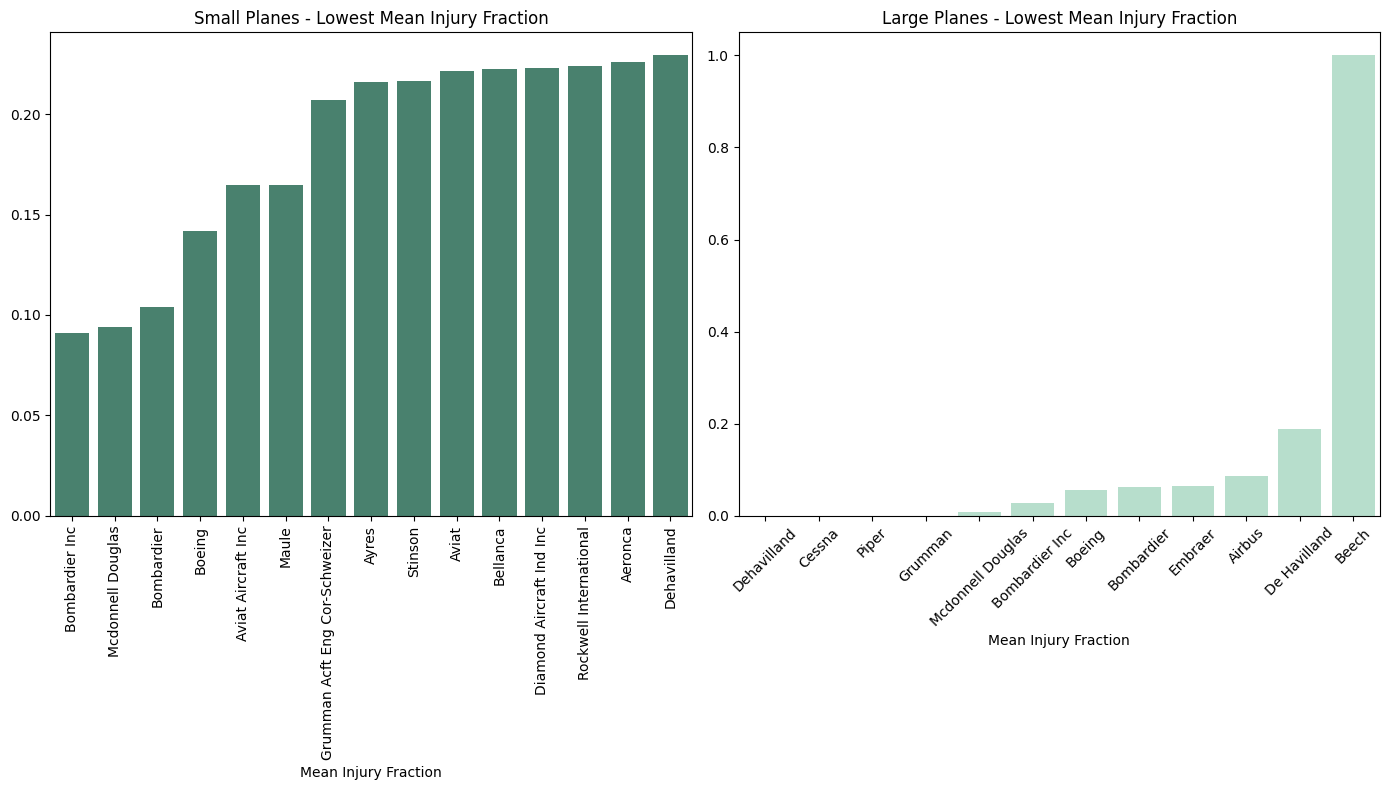

In [6]:
# Plot mean injury fraction for small and large makes side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Small planes
sns.barplot(x=small_makes.index, y=small_makes.values, ax=axes[0],color ='#408A71')
axes[0].set_title('Small Planes - Lowest Mean Injury Fraction')
axes[0].set_xlabel('Mean Injury Fraction')
axes[0].tick_params(axis='x', rotation=90)

# Large planes
sns.barplot(x=large_makes.index, y=large_makes.values, ax=axes[1],color ='#B0E4CC')
axes[1].set_title('Large Planes - Lowest Mean Injury Fraction')
axes[1].set_xlabel('Mean Injury Fraction')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Observation: Large plane makes generally show lower injury fractions compared to small plane makes.This suggests that larger aircraft tend to be safer for passengers in the event of an accident.



In [23]:
# Summary statistics by make for small planes
small_planes.groupby('make')[['injury_fraction', 'is_destroyed']].mean().sort_values('injury_fraction').head(10)


,injury_fraction,is_destroyed
make,,
Bombardier Inc,0.090909,0.090909
Mcdonnell Douglas,0.094048,0.108108
Bombardier,0.103846,0.055556
Boeing,0.141973,0.067183
Aviat Aircraft Inc,0.164474,0.040000
Maule,0.164806,0.041860
Grumman Acft Eng Cor-Schweizer,0.206897,0.017241
Ayres,0.215686,0.134615
Stinson,0.216408,0.023256


Observation: The table shows that Bombardier Inc and Mcdonnell Douglas ave the lowest mean injury fractions for small planes.These makes also have relatively low destruction rates,making them strong recommendations for small aircraft. 
 


In [24]:
# Summary statistics by make for large planes
large_planes.groupby('make')[['injury_fraction', 'is_destroyed']].mean().sort_values('injury_fraction').head(10)

,injury_fraction,is_destroyed
make,,
Dehavilland,0.000000,0.000000
Cessna,0.000000,NaN
Piper,0.000000,NaN
Grumman,0.000000,NaN
Mcdonnell Douglas,0.007827,0.111111
Bombardier Inc,0.028690,0.038462
Boeing,0.056771,0.096774
Bombardier,0.063701,0.055556
Embraer,0.065274,0.088889


Observation: For large planes,Dehavilland,Cessna,Piper and Grumman all show 0 mean injury fractions. This means no serious or fatal injuries were recorded in their accidents,making them the safest large plane makes in our dataset.



**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

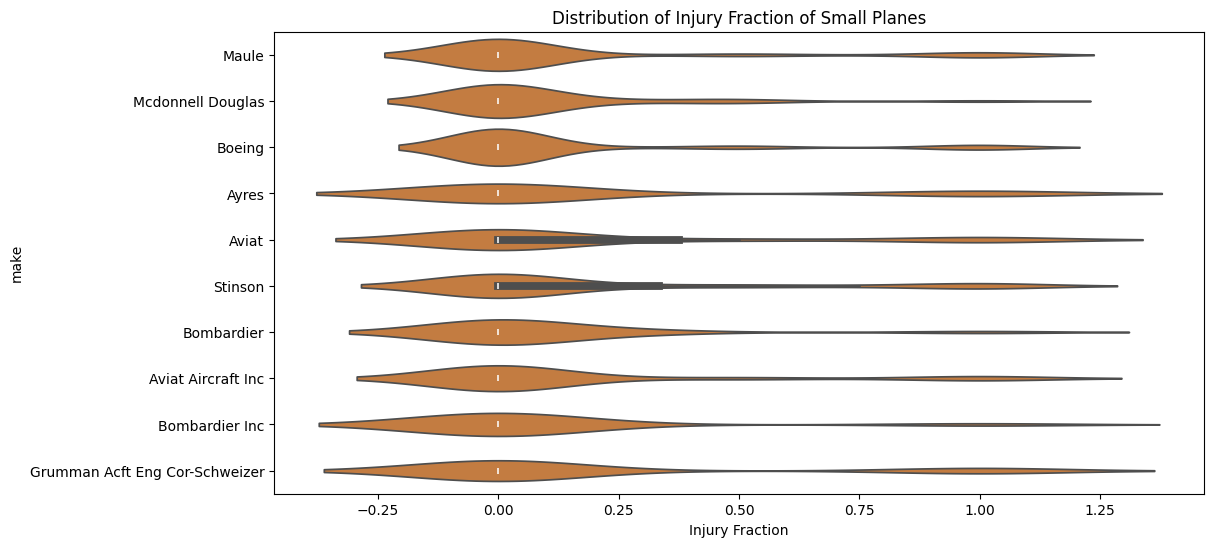

In [7]:
# Get top 10 lowest mean injury fraction for small planes
top10_small = small_makes.head(10).index

# Filter small planes for those makes only
small_top10 = small_planes[small_planes['make'].isin(top10_small)].reset_index(drop=True)

# Violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='injury_fraction', y='make', data=small_top10, color ='#D97A2B')
plt.title('Distribution of Injury Fraction of Small Planes')
plt.xlabel('Injury Fraction')
plt.show()

Observation: Most small plane makes have injury fractions clustered near 0, but some makes show a wider spread meaning occasional higher injury events do occur. 


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

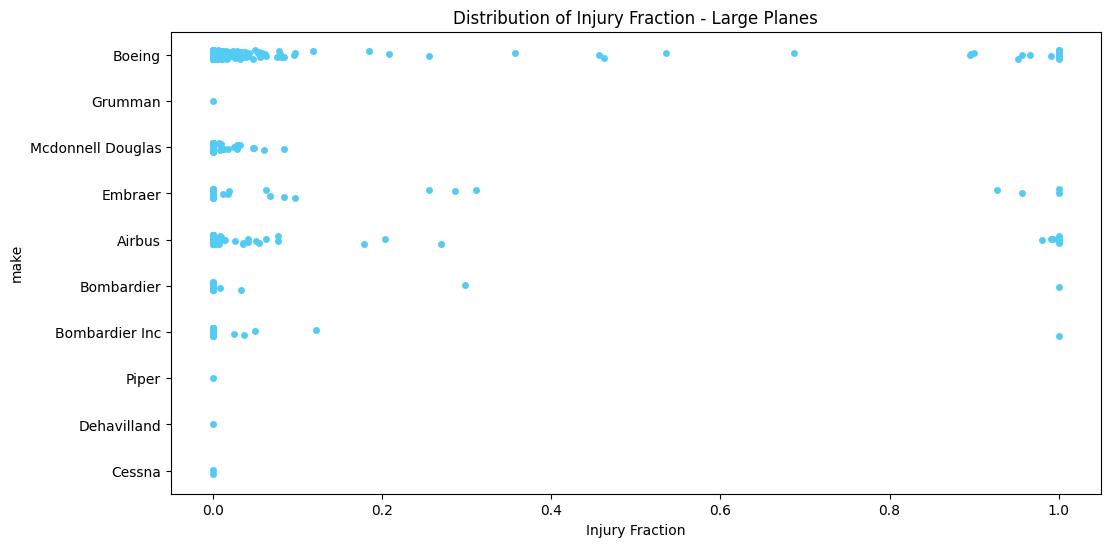

In [8]:
# Get top 10 lowest mean injury fraction for large planes
top10_large = large_makes.head(10).index

# Filter large planes for those makes only
large_top10 = large_planes[large_planes['make'].isin(top10_large)].reset_index(drop=True)

# Strip plot
plt.figure(figsize=(12, 6))
sns.stripplot(x='injury_fraction', y='make', data=large_top10,color = '#53CBF3')
plt.title('Distribution of Injury Fraction - Large Planes')
plt.xlabel('Injury Fraction')
plt.show()

Observation: Most large plane accidents result in very low injury fractions, meaning passengers are generally safe.

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

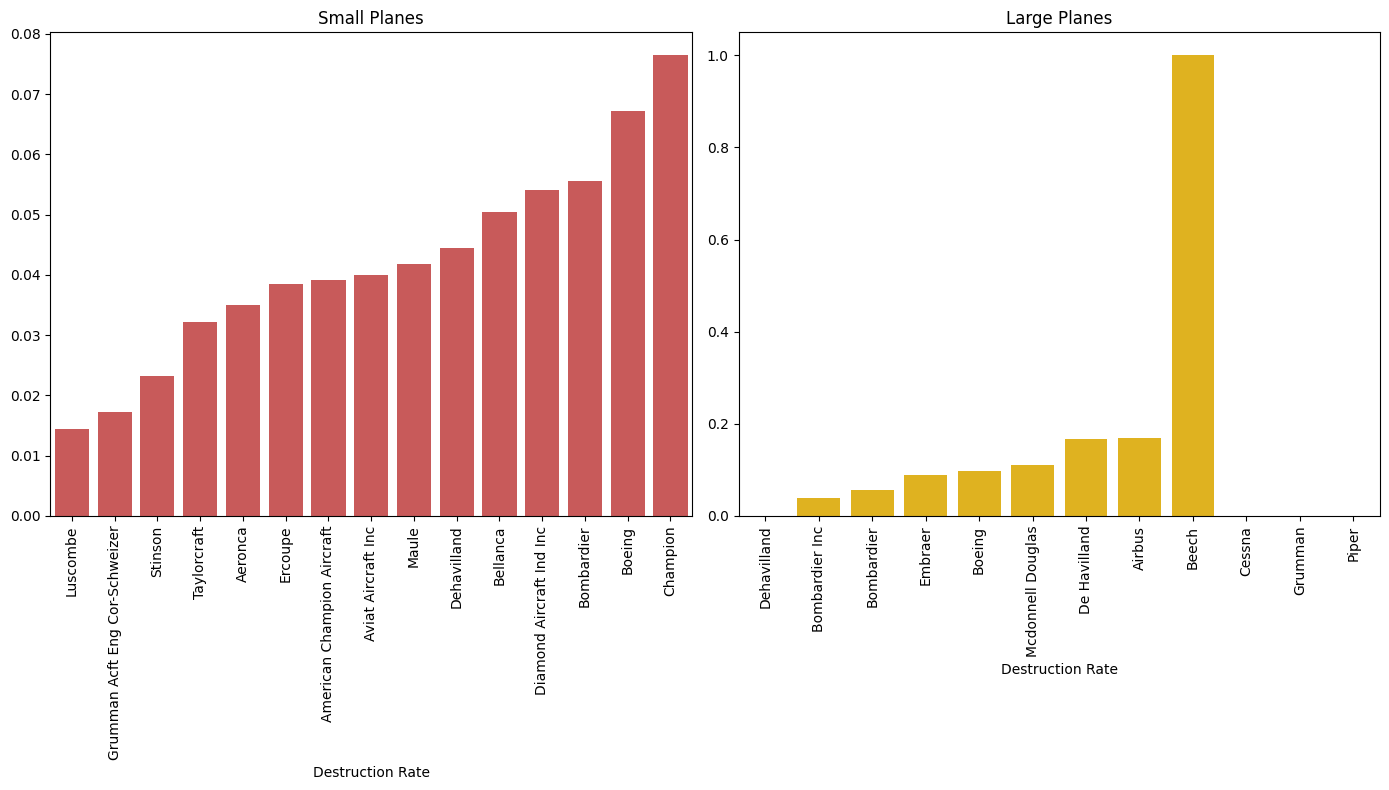

In [9]:
# Destruction rate for small planes by make
small_destroyed = small_planes.groupby('make')['is_destroyed'].mean().sort_values().head(15)

# Destruction rate for large planes by make
large_destroyed = large_planes.groupby('make')['is_destroyed'].mean().sort_values().head(15)

# Barplot
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.barplot(x=small_destroyed.index, y=small_destroyed.values, ax=axes[0], color='#DA4848')
axes[0].set_title('Small Planes')
axes[0].set_xlabel('Destruction Rate')
axes[0].tick_params(axis='x', rotation=90)

sns.barplot(x=large_destroyed.index, y=large_destroyed.values, ax=axes[1], color='#FFC300')
axes[1].set_title('Large Planes')
axes[1].set_xlabel('Destruction Rate')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Observation: Several large plane makes show 0% destruction rate.Small planes have higher and more varied destruction rates. 

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

## Discussion of Makes

### Small Planes

From the bar plot and violin plot, makes like Bombardier,Mcdonnell Douglas and Aviat Aircraft show the lowest mean injury fractions.These makes also have low destruction rates,making them the top recommendations for small planes.  

### Large Planes

From the strip plot,makes like Boeing,Bombardier and Embraer show consistently low injury fractions.Boeing in particular has a large number of records,making its results more reliable.

Large plane makes are generally safer than small plane makes.When choosing a make,one should consider both the injury fraction and the destruction rate together to know the extent of safety.





### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

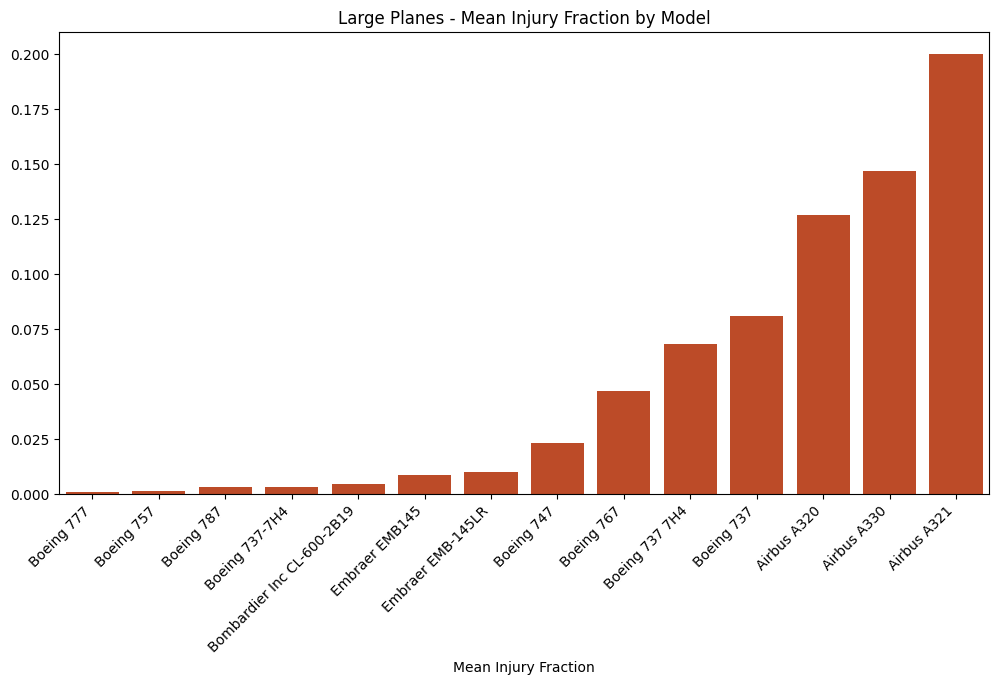

In [10]:
# Filter models with at least 10 records
large_model_counts = large_planes.groupby('make_model')['injury_fraction'].count()
valid_large_models = large_model_counts[large_model_counts >= 10].index
large_filtered = large_planes[large_planes['make_model'].isin(valid_large_models)].reset_index(drop=True)

# Mean injury fraction by model
large_model_means = large_filtered.groupby('make_model')['injury_fraction'].mean().sort_values()

# Bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=large_model_means.index, y=large_model_means.values, color='#D53E0F')
plt.title('Large Planes - Mean Injury Fraction by Model')
plt.xlabel('Mean Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.show()

Observation: After filtering for models with at least 10 records,Boeing 777 shows the lowest mean injury fractions for large planes and overall Boeing models tend to be safer than airbus models.


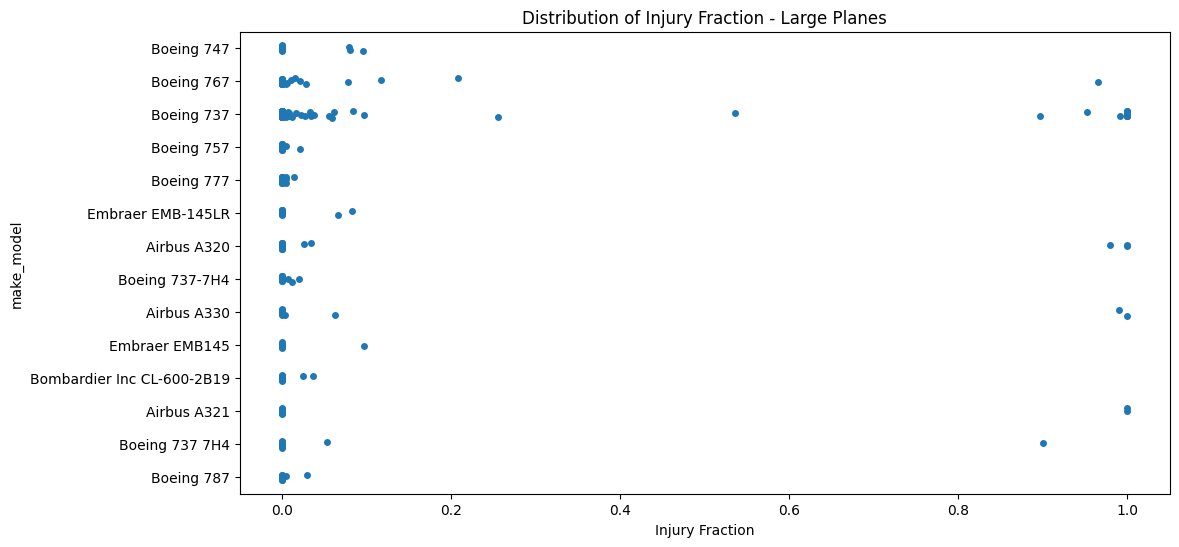

In [11]:
plt.figure(figsize=(12, 6))
sns.stripplot(x='injury_fraction', y='make_model', data=large_filtered)
plt.title('Distribution of Injury Fraction - Large Planes')
plt.xlabel('Injury Fraction')
plt.show()

Observation: Most large plane models have injury fractions clustered near 0,meaning passengers are rarely seriously injured in accidents. 


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

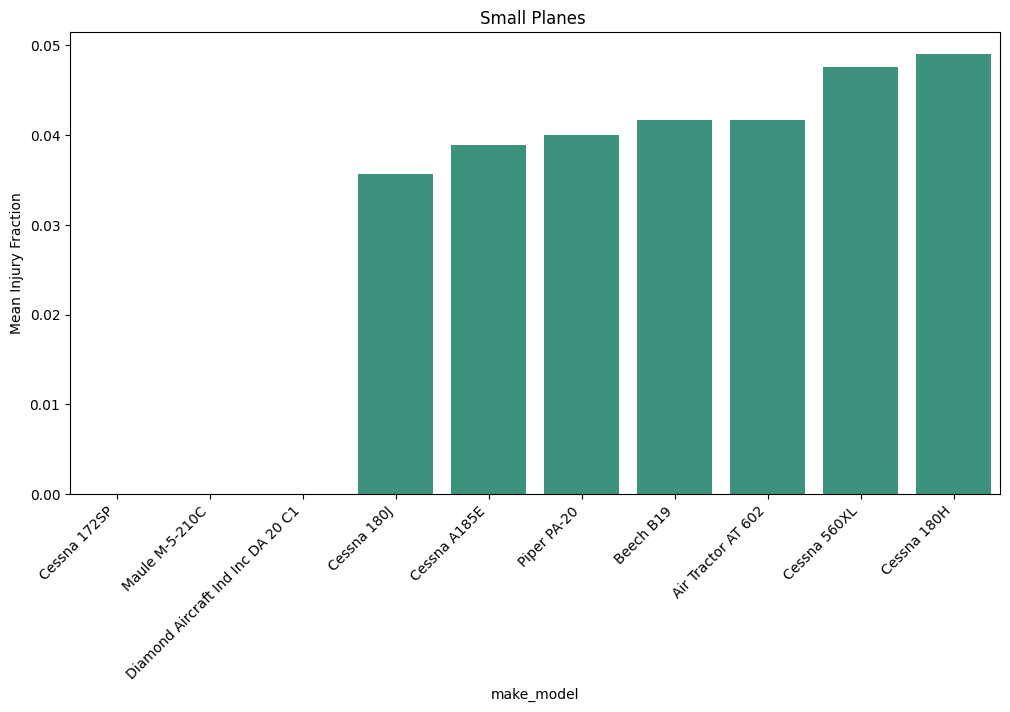

In [12]:
small_model_counts = small_planes.groupby('make_model')['injury_fraction'].count()
valid_small_models = small_model_counts[small_model_counts >= 10].index
small_filtered = small_planes[small_planes['make_model'].isin(valid_small_models)].reset_index(drop=True)

small_model_means = small_filtered.groupby('make_model')['injury_fraction'].mean().sort_values().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=small_model_means.index, y=small_model_means.values, color='#2FA084')
plt.title('Small Planes ')
plt.ylabel('Mean Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.show()


Observation: Cessna 172 stands out as the most consistently safe small plane.

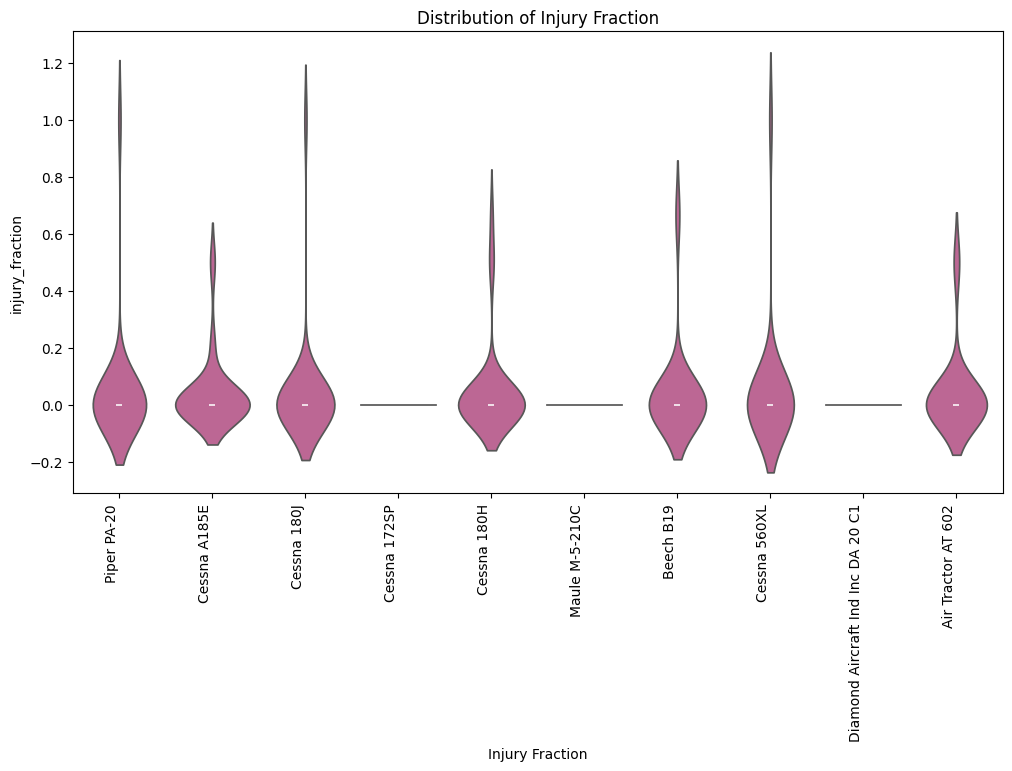

In [13]:
# Filter small
top10_small_models = small_model_means.index
small_top10_filtered = small_filtered[small_filtered['make_model'].isin(top10_small_models)].reset_index(drop=True)

# Violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='make_model', y='injury_fraction', data=small_top10_filtered, color='#CA5995')
plt.title('Distribution of Injury Fraction')
plt.xlabel('Injury Fraction')
plt.xticks(rotation=90, ha='right')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Observation:Small planes;The Cessna 172 stands out as the safest small plane model with the most records and a consistently low injury fraction.

Large planes: Boeing 777 is the most recorded large plane model and shows a relatively low injury fraction given the number of flights.This makes it a reliable choice for larger passenger operations


### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

#### Weather Condition

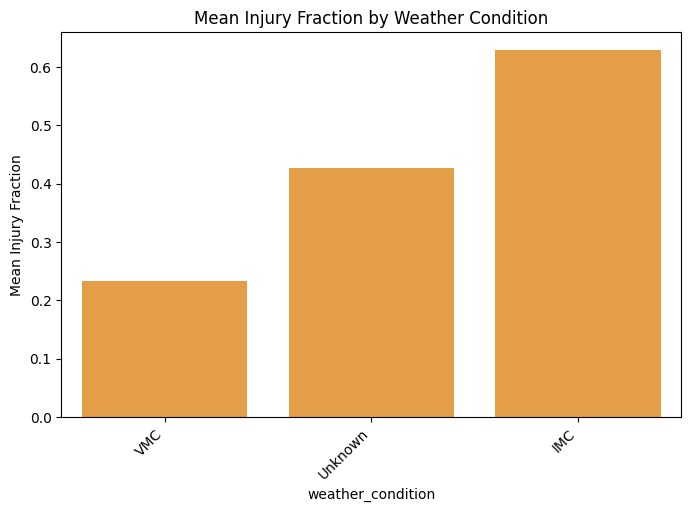

In [14]:
# Mean injury fraction by weather condition
weather_injury = airline_df.groupby('weather_condition')['injury_fraction'].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=weather_injury.index, y=weather_injury.values, color='#FFA02E')
plt.title('Mean Injury Fraction by Weather Condition')
plt.ylabel('Mean Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.show()

Observation: The IMC(bad weather condition) shows much higher injury fraction compared to the VMC(good weather condition).This tells us that bad weather significantly increases the risk of serious injuries in accidents. Flying in good weather conditions is clearly safer for passengers.

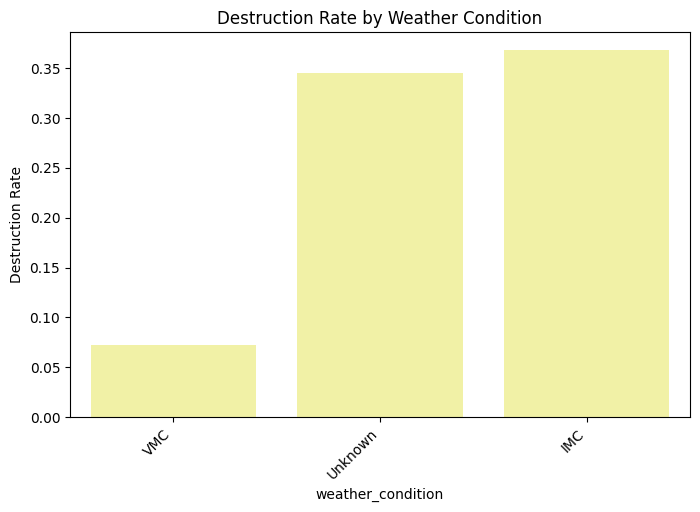

In [17]:
# Destruction rate by weather condition
weather_destroyed = airline_df.groupby('weather_condition')['is_destroyed'].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=weather_destroyed.index, y=weather_destroyed.values, color='#FEFD99')
plt.title('Destruction Rate by Weather Condition')
plt.ylabel('Destruction Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

Observation: IMC weather conditions also lead to higher destruction rates compared to VMC. Bad weather makes it harder for pilots to control the plane, increasing the chance of total destruction. 


#### Number of engines

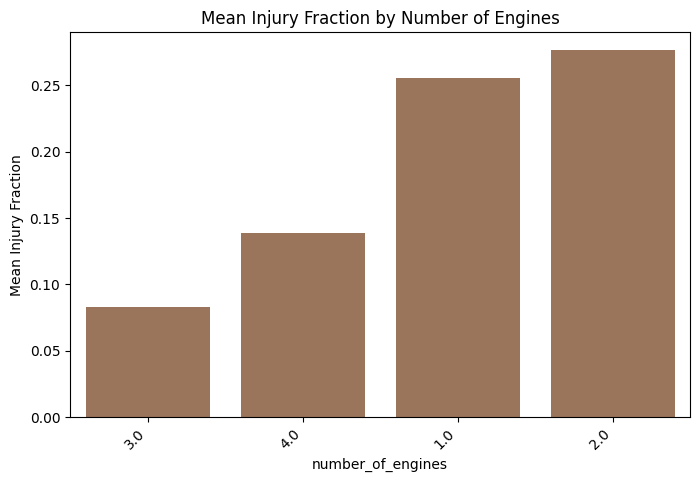

In [19]:
# Mean injury fraction by number of engines
engine_injury = airline_df.groupby('number_of_engines')['injury_fraction'].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=engine_injury.index.astype(str), y=engine_injury.values, color='#A47251')
plt.title('Mean Injury Fraction by Number of Engines')
plt.ylabel('Mean Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.show()

Observation: Planes with more engines tend to have lower injury fractions. Single engine planes show the highest injury rates, while planes with 3 and 4 engines are generally safer.This makes sense because if one engine fails on a multi-engine plane, the other engines can keep the plane flying safely.


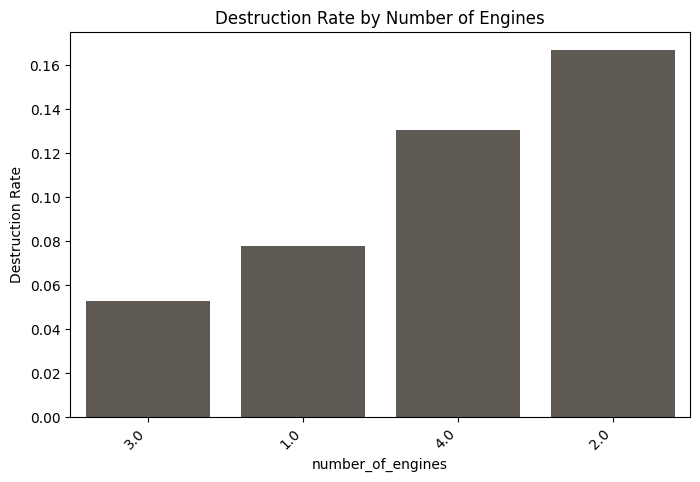

In [21]:
# Destruction rate by number of engines
engine_destroyed = airline_df.groupby('number_of_engines')['is_destroyed'].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=engine_destroyed.index.astype(str), y=engine_destroyed.values, color='#605B51')
plt.title('Destruction Rate by Number of Engines')
plt.ylabel('Destruction Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

Observation: Single engine planes have the highest destruction rates.Planes with 3 or 4 engines are least likely to be completely destroyed in an accident. 
